In [1]:
import pandas as pd
import numpy as np
import re
import streamlit as st
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("Dataset_task_7.csv", sep=';',decimal=',')

In [3]:
df.head()

,transaction_id,date,product,category,region,sales_channel,units_sold,unit_price_eur,discount_pct,revenue_eur,cost_eur,profit_eur,profit_margin_pct
0,TRX-00001,2025-10-14,Fitness Tracker,Sports,North,Marketplace,16,77.28,10%,"1.112,83","667,95",444.88,"40,0%"
1,TRX-00002,2025-07-04,Digital Scale,Home,West,Online,13,42.48,0%,"552,24","261,27",290.97,"52,7%"
2,TRX-00003,2025-08-17,Wireless Headphones,Electronics,East,Online,9,89.48,0%,"805,32","441,43",363.89,"45,2%"
3,TRX-00004,2025-02-14,Air Purifier,Home,West,Retail Store,7,136.61,10%,"860,64","575,56",285.08,"33,1%"
4,TRX-00005,2025-06-22,Ergonomic Mouse,Office Supplies,North,Online,12,40.08,15%,"408,82","214,84",193.98,"47,5%"


In [4]:
df.dtypes

transaction_id           str
date                     str
product                  str
category                 str
region                   str
sales_channel            str
units_sold             int64
unit_price_eur       float64
discount_pct             str
revenue_eur              str
cost_eur                 str
profit_eur           float64
profit_margin_pct        str
dtype: object

In [5]:
isnull_count = df.isnull().sum()
print("Number of Nulls:", isnull_count)

# Total Nulls in Dataset
Total_isnull_count = isnull_count.sum()

print("Total Nulls:", Total_isnull_count)

Number of Nulls: transaction_id       0
date                 0
product              0
category             0
region               0
sales_channel        0
units_sold           0
unit_price_eur       0
discount_pct         0
revenue_eur          0
cost_eur             0
profit_eur           0
profit_margin_pct    0
dtype: int64
Total Nulls: 0


In [9]:
# convert numeric-looking strings to floats
import numbers

def parse_number(value):
    if pd.isna(value):
        return np.nan

    # Already numeric: do not treat "." as a thousands separator
    if isinstance(value, numbers.Number):
        return float(value)

    value = str(value).strip().replace("%", "")

    # Handle separators based on their presence
    if "," in value and "." in value:
        # Example: 1.234,56 -> 1234.56
        value = value.replace(".", "").replace(",", ".")
    elif "," in value:
        # Example: 1234,56 -> 1234.56
        value = value.replace(",", ".")
    # If only "." exists, assume it is already a decimal point

    return pd.to_numeric(value, errors="coerce")


cols = [
    "unit_price_eur",
    "discount_pct",
    "revenue_eur",
    "cost_eur",
    "profit_eur",
    "profit_margin_pct",
]

for col in cols:
    df[col] = df[col].map(parse_number)


In [10]:
df.dtypes

transaction_id           str
date                     str
product                  str
category                 str
region                   str
sales_channel            str
units_sold             int64
unit_price_eur       float64
discount_pct           int64
revenue_eur          float64
cost_eur             float64
profit_eur           float64
profit_margin_pct    float64
dtype: object

In [11]:
df.head()

,transaction_id,date,product,category,region,sales_channel,units_sold,unit_price_eur,discount_pct,revenue_eur,cost_eur,profit_eur,profit_margin_pct
0,TRX-00001,2025-10-14,Fitness Tracker,Sports,North,Marketplace,16,77.28,10,1112.83,667.95,444.88,40.0
1,TRX-00002,2025-07-04,Digital Scale,Home,West,Online,13,42.48,0,552.24,261.27,290.97,52.7
2,TRX-00003,2025-08-17,Wireless Headphones,Electronics,East,Online,9,89.48,0,805.32,441.43,363.89,45.2
3,TRX-00004,2025-02-14,Air Purifier,Home,West,Retail Store,7,136.61,10,860.64,575.56,285.08,33.1
4,TRX-00005,2025-06-22,Ergonomic Mouse,Office Supplies,North,Online,12,40.08,15,408.82,214.84,193.98,47.5


In [12]:
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [transaction_id, date, product, category, region, sales_channel, units_sold, unit_price_eur, discount_pct, revenue_eur, cost_eur, profit_eur, profit_margin_pct]
Index: []


In [13]:
total_revenue = df["revenue_eur"].sum()
total_profit = df["profit_eur"].sum()
profit_margin = (total_profit / total_revenue) * 100
total_orders = df["transaction_id"].nunique()
average_order_value = total_revenue / total_orders
units_sold = df["units_sold"].sum()

print(f"Total Revenue: ${total_revenue:.2f}")
print(f"Total Profit: ${total_profit:.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Average Order Value: ${average_order_value:.2f}")
print(f"Units Sold: {units_sold}")

Total Revenue: $158925.67
Total Profit: $68282.72
Profit Margin: 42.97%
Average Order Value: $397.31
Units Sold: 3090


In [14]:
def summarize_by(df, column):
    summary = (
        df.groupby(column, dropna=False)
          .agg(
              sales_eur=("revenue_eur", "sum"),
              profit_eur=("profit_eur", "sum"),
              transactions=("revenue_eur", "size")
          )
    )

    summary["profit_margin_pct"] = (
        summary["profit_eur"] / summary["sales_eur"] * 100
    )

    return summary.sort_values("sales_eur", ascending=False)

In [15]:
category_summary = summarize_by(df, "category")
product_summary = summarize_by(df, "product")
region_summary = summarize_by(df, "region")
channel_summary = summarize_by(df, "sales_channel")

In [16]:
category_summary

,sales_eur,profit_eur,transactions,profit_margin_pct
category,,,,
Electronics,54142.73,20827.57,102,38.467898
Home,52252.65,20825.54,96,39.855471
Sports,26589.72,13971.61,106,52.545157
Office Supplies,25940.57,12658.00,96,48.796152


In [17]:
sns.set_theme(style="whitegrid")

def plot_sales(summary, title):
    data = summary.sort_values("sales_eur")

    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=data.reset_index(),
        x="sales_eur",
        y=data.index,
        color="steelblue"
    )
    plt.title(title)
    plt.xlabel("Sales (€)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

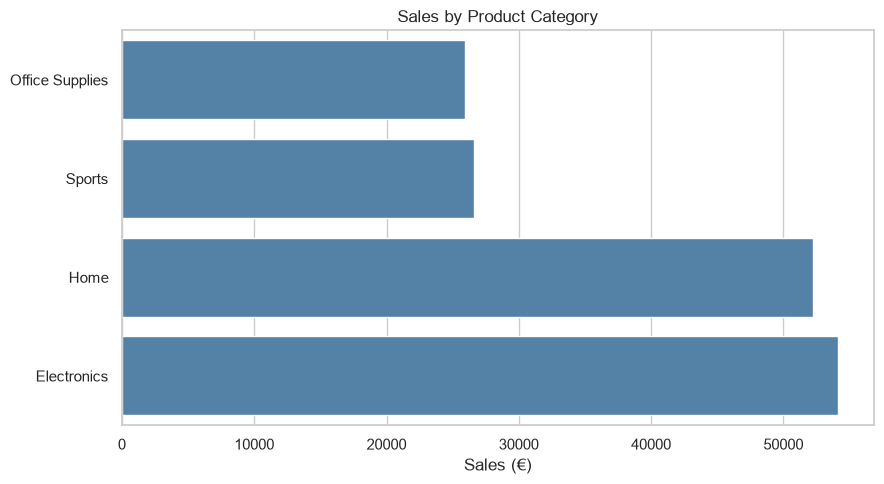

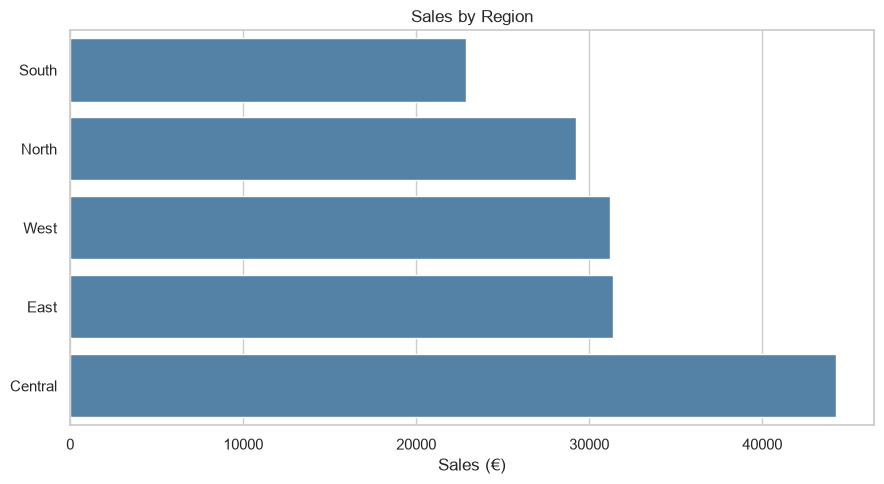

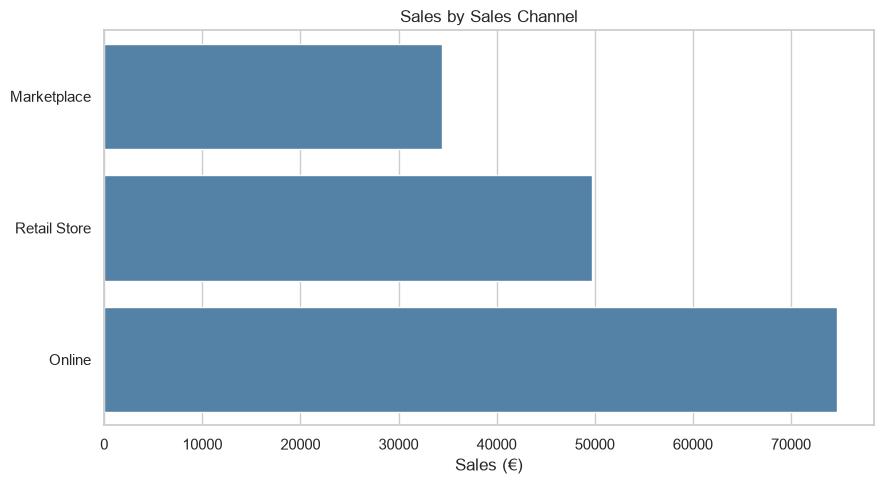

In [18]:
plot_sales(category_summary, "Sales by Product Category")
plot_sales(region_summary, "Sales by Region")
plot_sales(channel_summary, "Sales by Sales Channel")

In [19]:
def plot_profit(summary, title):
    data = summary.sort_values("profit_eur")

    colors = [
        "indianred" if value < 0 else "seagreen"
        for value in data["profit_eur"]
    ]

    plt.figure(figsize=(9, 5))
    plt.barh(data.index.astype(str), data["profit_eur"], color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(title)
    plt.xlabel("Profit (€)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

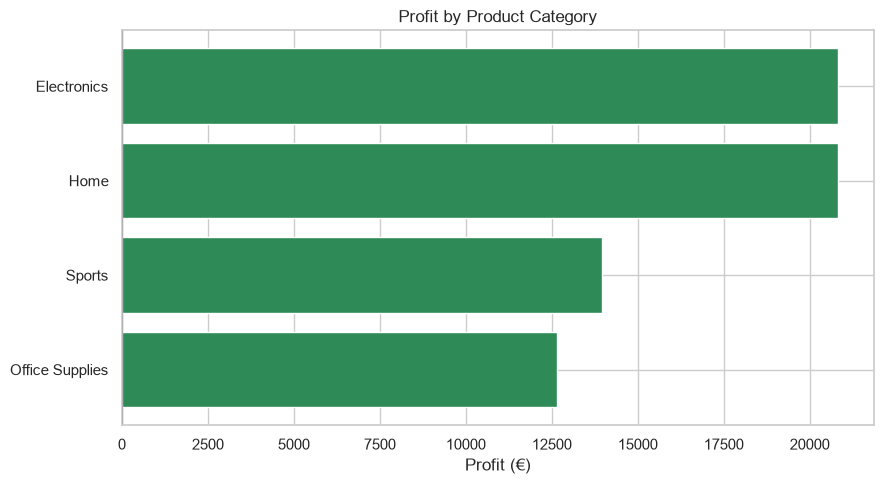

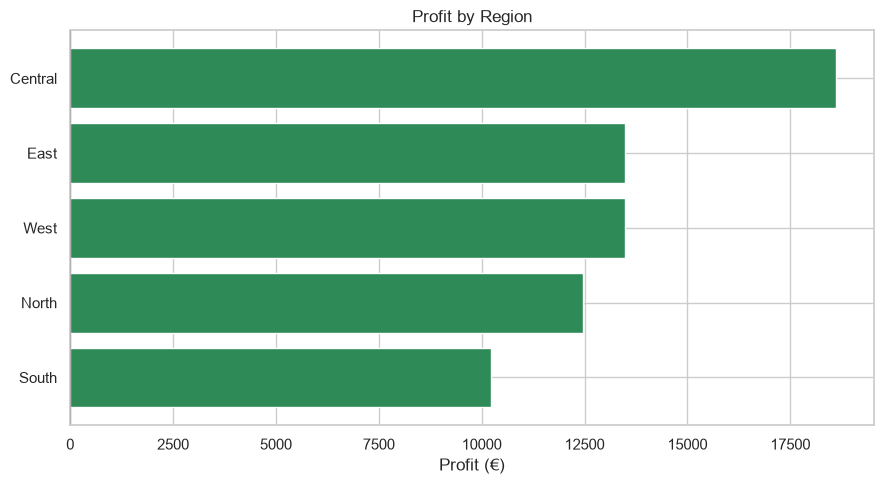

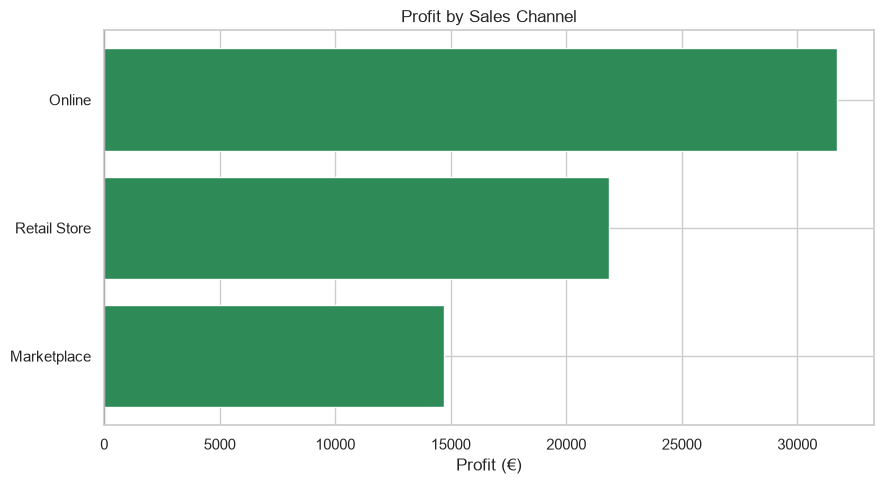

In [20]:
plot_profit(category_summary, "Profit by Product Category")
plot_profit(region_summary, "Profit by Region")
plot_profit(channel_summary, "Profit by Sales Channel")

In [21]:
def plot_margin(summary, title):
    data = summary.sort_values("profit_margin_pct")

    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=data.reset_index(),
        x="profit_margin_pct",
        y=data.index,
        color="darkorange"
    )
    plt.title(title)
    plt.xlabel("Profit margin (%)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

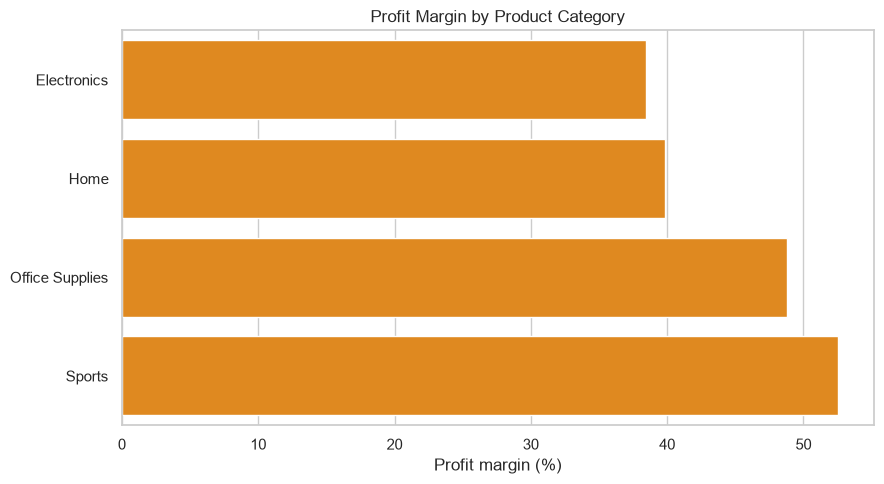

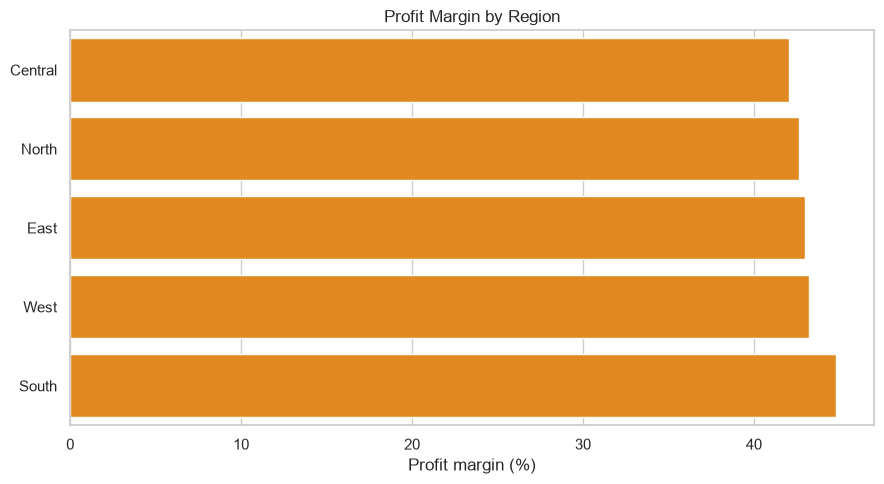

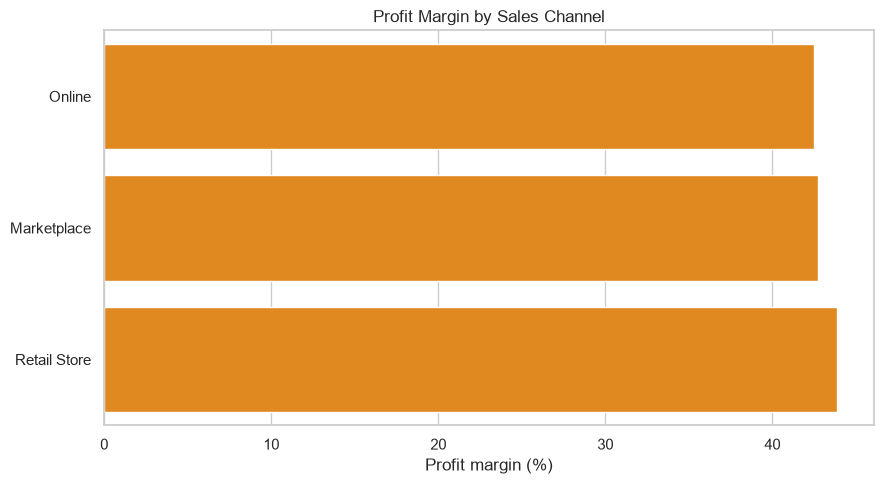

In [22]:
plot_margin(category_summary, "Profit Margin by Product Category")
plot_margin(region_summary, "Profit Margin by Region")
plot_margin(channel_summary, "Profit Margin by Sales Channel")

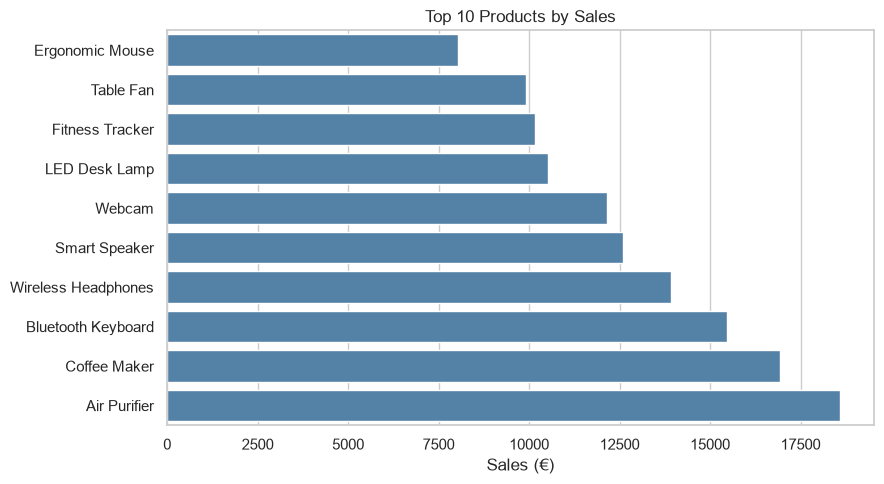

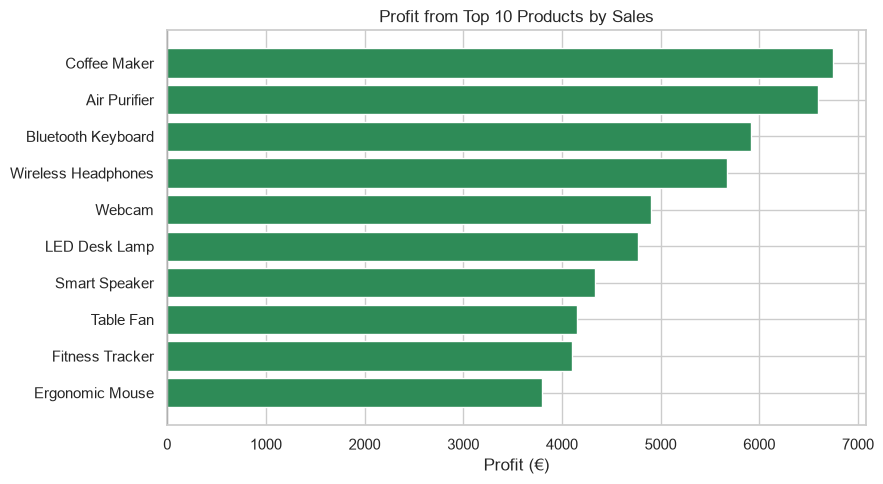

In [23]:
top_products = product_summary.head(10)

plot_sales(top_products, "Top 10 Products by Sales")
plot_profit(top_products, "Profit from Top 10 Products by Sales")

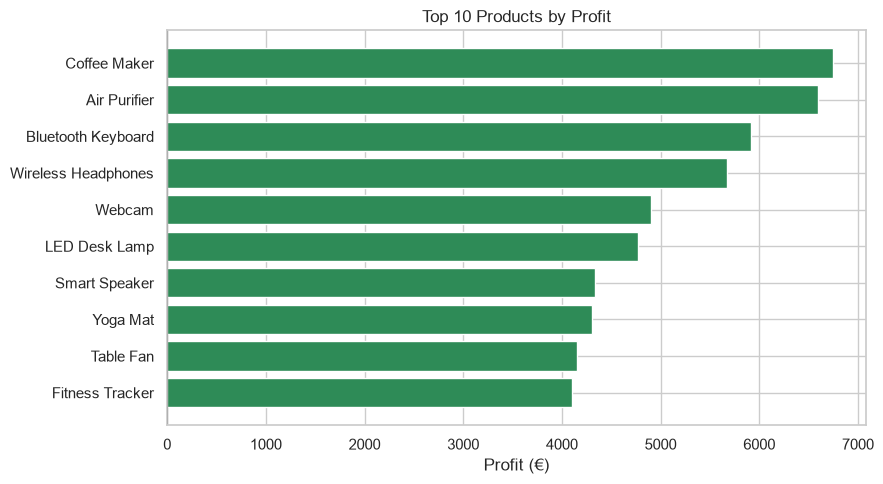

In [24]:
top_profit_products = product_summary.sort_values(
    "profit_eur",
    ascending=False
).head(10)

plot_profit(top_profit_products, "Top 10 Products by Profit")

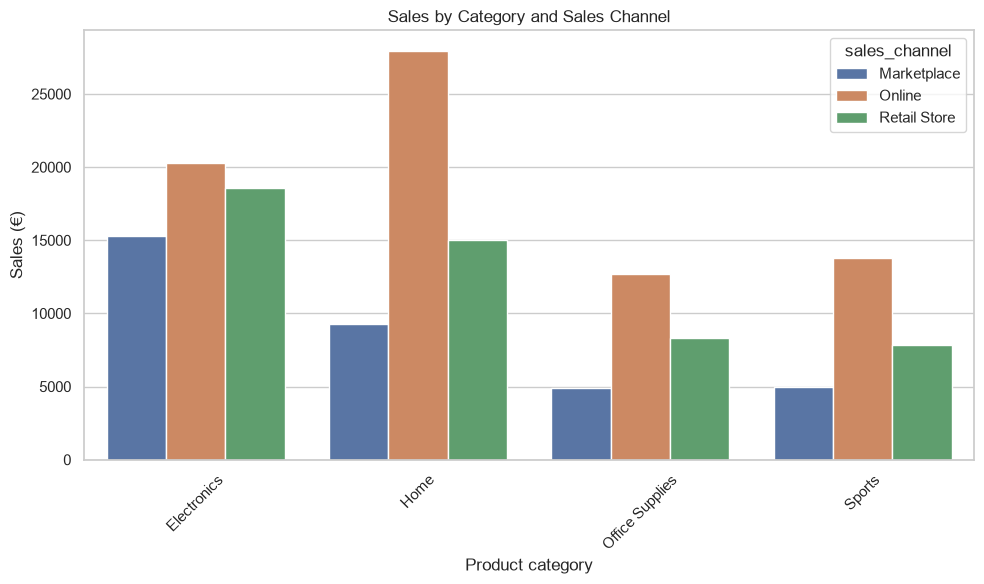

In [25]:
category_channel = (
    df.groupby(["category", "sales_channel"], as_index=False)
      .agg(
          sales_eur=("revenue_eur", "sum"),
          profit_eur=("profit_eur", "sum")
      )
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_channel,
    x="category",
    y="sales_eur",
    hue="sales_channel"
)
plt.title("Sales by Category and Sales Channel")
plt.xlabel("Product category")
plt.ylabel("Sales (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

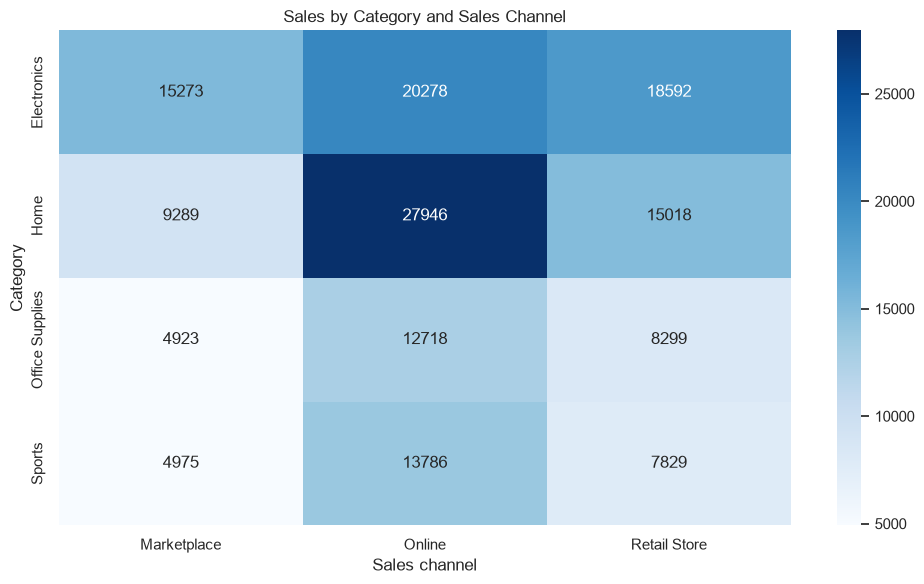

In [26]:
sales_heatmap = df.pivot_table(
    index="category",
    columns="sales_channel",
    values="revenue_eur",
    aggfunc="sum"
)

plt.figure(figsize=(10, 6))
sns.heatmap(sales_heatmap, annot=True, fmt=".0f", cmap="Blues")
plt.title("Sales by Category and Sales Channel")
plt.xlabel("Sales channel")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [27]:
df["discount_rate"] = df["discount_pct"] / 100  # if discount_pct is 10 for 10%
df["net_revenue"] = df["revenue_eur"] * (1 - df["discount_rate"])
df["gross_profit"] = df["profit_eur"]

In [28]:
df["discount_bucket"] = pd.qcut(df["discount_pct"], q=10, duplicates="drop")

In [29]:
summary = (
    df.groupby("discount_bucket", observed=True)
      .agg(
          revenue_eur=("revenue_eur", "sum"),
          profit_eur=("profit_eur", "sum"),
          units_sold=("quantity", "sum") if "quantity" in df.columns else ("revenue_eur", "size"),
          avg_margin_pct=("profit_margin_pct", "mean")
      )
      .reset_index()
)

summary["profit_margin_pct"] = summary["profit_eur"] / summary["revenue_eur"] * 100
summary

,discount_bucket,revenue_eur,profit_eur,units_sold,avg_margin_pct,profit_margin_pct
0,"(-0.001, 5.0]",69843.62,32662.57,153,50.637255,46.765288
1,"(5.0, 10.0]",38435.77,16535.86,103,47.574757,43.022060
2,"(10.0, 15.0]",27706.80,10889.90,72,43.797222,39.304070
3,"(15.0, 20.0]",15685.80,5698.38,48,42.233333,36.328271
4,"(20.0, 25.0]",7253.68,2496.01,24,38.470833,34.410258


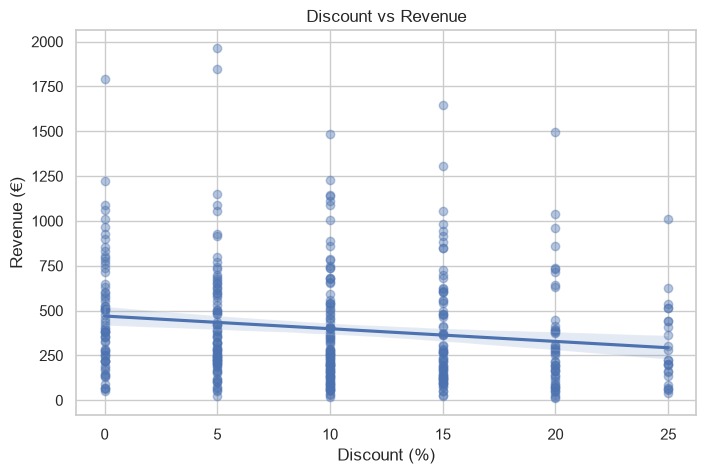

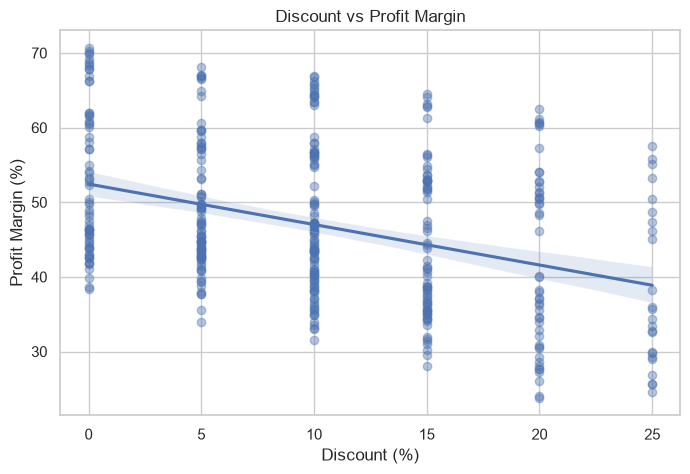

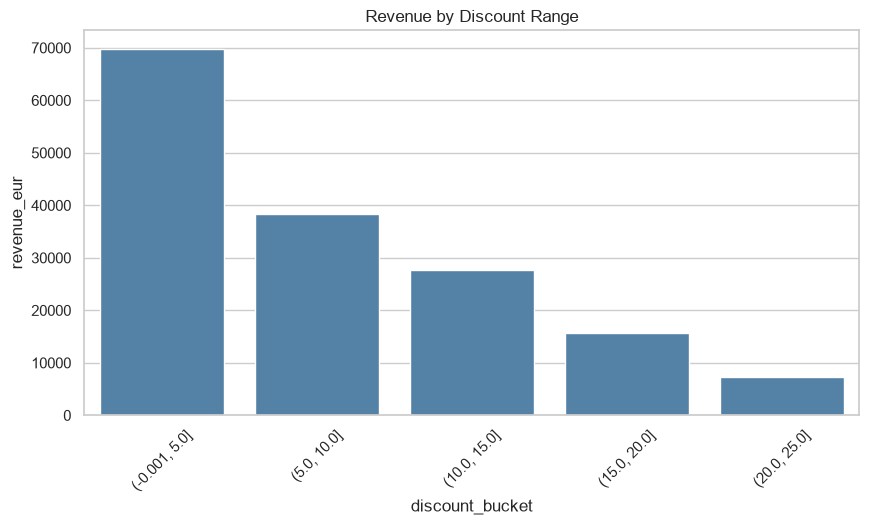

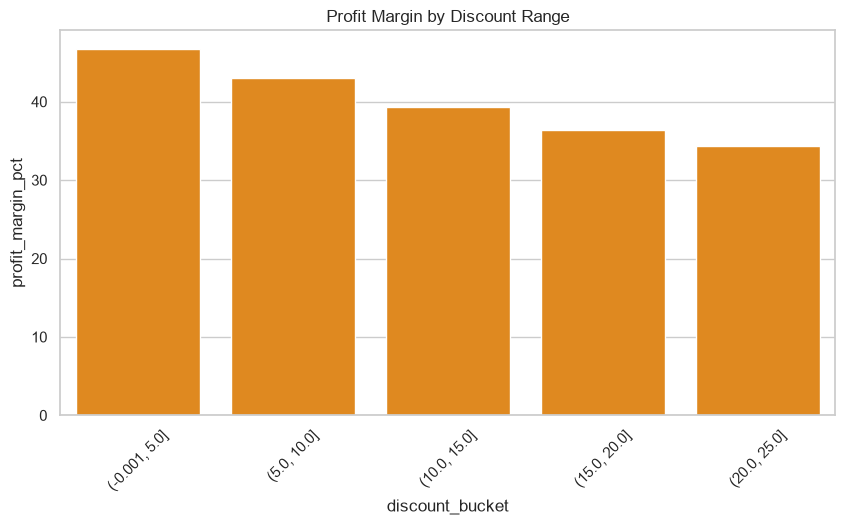

In [30]:
# 1) Discount vs revenue
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="discount_pct", y="revenue_eur", scatter_kws={"alpha": 0.4})
plt.title("Discount vs Revenue")
plt.xlabel("Discount (%)")
plt.ylabel("Revenue (€)")
plt.show()

# 2) Discount vs profit margin
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="discount_pct", y="profit_margin_pct", scatter_kws={"alpha": 0.4})
plt.title("Discount vs Profit Margin")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")
plt.show()

# 3) Revenue + profit by discount bucket
summary = summary.sort_values("discount_bucket")

plt.figure(figsize=(10, 5))
sns.barplot(data=summary, x="discount_bucket", y="revenue_eur", color="steelblue")
plt.title("Revenue by Discount Range")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=summary, x="discount_bucket", y="profit_margin_pct", color="darkorange")
plt.title("Profit Margin by Discount Range")
plt.xticks(rotation=45)
plt.show()

In [31]:
corr_rev = df["discount_pct"].corr(df["revenue_eur"])
corr_profit = df["discount_pct"].corr(df["profit_margin_pct"])
corr_profit_eur = df["discount_pct"].corr(df["profit_eur"])

print("Discount vs revenue correlation:", corr_rev)
print("Discount vs profit margin correlation:", corr_profit)
print("Discount vs profit correlation:", corr_profit_eur)

Discount vs revenue correlation: -0.1605319828207825
Discount vs profit margin correlation: -0.3702060115495916
Discount vs profit correlation: -0.32172158999509237


In [32]:
product_summary = (
    df.groupby("product", dropna=False)
      .agg(
          revenue_eur=("revenue_eur", "sum"),
          profit_eur=("profit_eur", "sum"),
          units_sold=("quantity", "sum") if "quantity" in df.columns else ("revenue_eur", "size")
      )
      .reset_index()
)

product_summary["profit_margin_pct"] = (
    product_summary["profit_eur"] / product_summary["revenue_eur"] * 100
)

# sort by each metric
best_by_revenue = product_summary.sort_values("revenue_eur", ascending=False).head(10)
best_by_profit = product_summary.sort_values("profit_eur", ascending=False).head(10)
best_by_units = product_summary.sort_values("units_sold", ascending=False).head(10)
best_by_margin = product_summary.sort_values("profit_margin_pct", ascending=False).head(10)

print("Top 10 by revenue:\n", best_by_revenue[["product", "revenue_eur", "profit_eur", "units_sold", "profit_margin_pct"]].head())
print("\nTop 10 by profit:\n", best_by_profit[["product", "revenue_eur", "profit_eur", "units_sold", "profit_margin_pct"]].head())
print("\nTop 10 by units sold:\n", best_by_units[["product", "revenue_eur", "profit_eur", "units_sold", "profit_margin_pct"]].head())
print("\nTop 10 by margin:\n", best_by_margin[["product", "revenue_eur", "profit_eur", "units_sold", "profit_margin_pct"]].head())

Top 10 by revenue:
                 product  revenue_eur  profit_eur  units_sold  \
0          Air Purifier     18599.69     6599.77          20   
2          Coffee Maker     16924.29     6744.74          24   
1    Bluetooth Keyboard     15468.87     5915.55          34   
14  Wireless Headphones     13926.46     5674.95          25   
10        Smart Speaker     12591.56     4332.33          19   

    profit_margin_pct  
0           35.483226  
2           39.852425  
1           38.241643  
14          40.749408  
10          34.406618  

Top 10 by profit:
                 product  revenue_eur  profit_eur  units_sold  \
2          Coffee Maker     16924.29     6744.74          24   
0          Air Purifier     18599.69     6599.77          20   
1    Bluetooth Keyboard     15468.87     5915.55          34   
14  Wireless Headphones     13926.46     5674.95          25   
13               Webcam     12155.84     4904.74          24   

    profit_margin_pct  
2           39.852425 

In [33]:
# rank each product based on each metric
ranked = product_summary.copy()
for col in ["revenue_eur", "profit_eur", "units_sold", "profit_margin_pct"]:
    ranked[f"{col}_rank"] = ranked[col].rank(method="dense", ascending=False)

# weighted score: revenue and profit matter most, units sold and margin also matter
ranked["overall_score"] = (
    0.35 * ranked["revenue_eur_rank"] +
    0.35 * ranked["profit_eur_rank"] +
    0.15 * ranked["units_sold_rank"] +
    0.15 * ranked["profit_margin_pct_rank"]
)

best_products = ranked.sort_values("overall_score", ascending=True).head(10)
worst_products = ranked.sort_values("overall_score", ascending=False).head(10)

print("Best-performing products:\n", best_products[[
    "product", "revenue_eur", "profit_eur", "units_sold", "profit_margin_pct", "overall_score"
]])
print("\nWorst-performing products:\n", worst_products[[
    "product", "revenue_eur", "profit_eur", "units_sold", "profit_margin_pct", "overall_score"
]])

Best-performing products:
                 product  revenue_eur  profit_eur  units_sold  \
2          Coffee Maker     16924.29     6744.74          24   
0          Air Purifier     18599.69     6599.77          20   
1    Bluetooth Keyboard     15468.87     5915.55          34   
14  Wireless Headphones     13926.46     5674.95          25   
7         LED Desk Lamp     10528.76     4773.62          26   
13               Webcam     12155.84     4904.74          24   
15             Yoga Mat      7815.47     4307.81          35   
10        Smart Speaker     12591.56     4332.33          19   
12            Table Fan      9917.89     4155.23          26   
5       Ergonomic Mouse      8032.81     3799.05          24   

    profit_margin_pct  overall_score  
2           39.852425           3.90  
0           35.483226           4.50  
1           38.241643           4.50  
14          40.749408           5.05  
7           45.338862           6.35  
13          40.348836           6.

In [34]:
# Pareto
# 1) Revenue by product
product_rev = (
    df.groupby("product", dropna=False)["revenue_eur"]
      .sum()
      .sort_values(ascending=False)
)

product_profit = (
    df.groupby("product", dropna=False)["profit_eur"]
      .sum()
      .sort_values(ascending=False)
)

# 2) Cumulative share
rev_share = product_rev / product_rev.sum()
profit_share = product_profit / product_profit.sum()

rev_cum = rev_share.cumsum()
profit_cum = profit_share.cumsum()

# 3) Find how many products account for 80% of each metric
rev_80 = (rev_cum <= 0.80).sum()
profit_80 = (profit_cum <= 0.80).sum()

print(f"Products contributing to 80% of revenue: {rev_80}")
print(f"Products contributing to 80% of profit: {profit_80}")

print("\nRevenue contributors:")
print(pd.DataFrame({
    "revenue_eur": product_rev,
    "revenue_share_pct": rev_share * 100,
    "cumulative_revenue_pct": rev_cum * 100
}).head(10))

print("\nProfit contributors:")
print(pd.DataFrame({
    "profit_eur": product_profit,
    "profit_share_pct": profit_share * 100,
    "cumulative_profit_pct": profit_cum * 100
}).head(10))

Products contributing to 80% of revenue: 9
Products contributing to 80% of profit: 10

Revenue contributors:
                     revenue_eur  revenue_share_pct  cumulative_revenue_pct
product                                                                    
Air Purifier            18599.69          11.703389               11.703389
Coffee Maker            16924.29          10.649186               22.352575
Bluetooth Keyboard      15468.87           9.733399               32.085975
Wireless Headphones     13926.46           8.762876               40.848851
Smart Speaker           12591.56           7.922924               48.771775
Webcam                  12155.84           7.648758               56.420533
LED Desk Lamp           10528.76           6.624959               63.045492
Fitness Tracker         10173.46           6.401395               69.446887
Table Fan                9917.89           6.240584               75.687471
Ergonomic Mouse          8032.81           5.054445    

In [35]:
category_rev = df.groupby("category", dropna=False)["revenue_eur"].sum().sort_values(ascending=False)
category_profit = df.groupby("category", dropna=False)["profit_eur"].sum().sort_values(ascending=False)

category_rev_share = category_rev / category_rev.sum()
category_profit_share = category_profit / category_profit.sum()

print("Revenue by category:")
print(pd.DataFrame({
    "revenue_eur": category_rev,
    "revenue_share_pct": category_rev_share * 100,
    "cumulative_share_pct": category_rev_share.cumsum() * 100
}))

print("\nProfit by category:")
print(pd.DataFrame({
    "profit_eur": category_profit,
    "profit_share_pct": category_profit_share * 100,
    "cumulative_share_pct": category_profit_share.cumsum() * 100
}))

Revenue by category:
                 revenue_eur  revenue_share_pct  cumulative_share_pct
category                                                             
Electronics         54142.73          34.067958             34.067958
Home                52252.65          32.878672             66.946630
Sports              26589.72          16.730916             83.677546
Office Supplies     25940.57          16.322454            100.000000

Profit by category:
                 profit_eur  profit_share_pct  cumulative_share_pct
category                                                           
Electronics        20827.57         30.501963             30.501963
Home               20825.54         30.498990             61.000953
Sports             13971.61         20.461414             81.462367
Office Supplies    12658.00         18.537633            100.000000


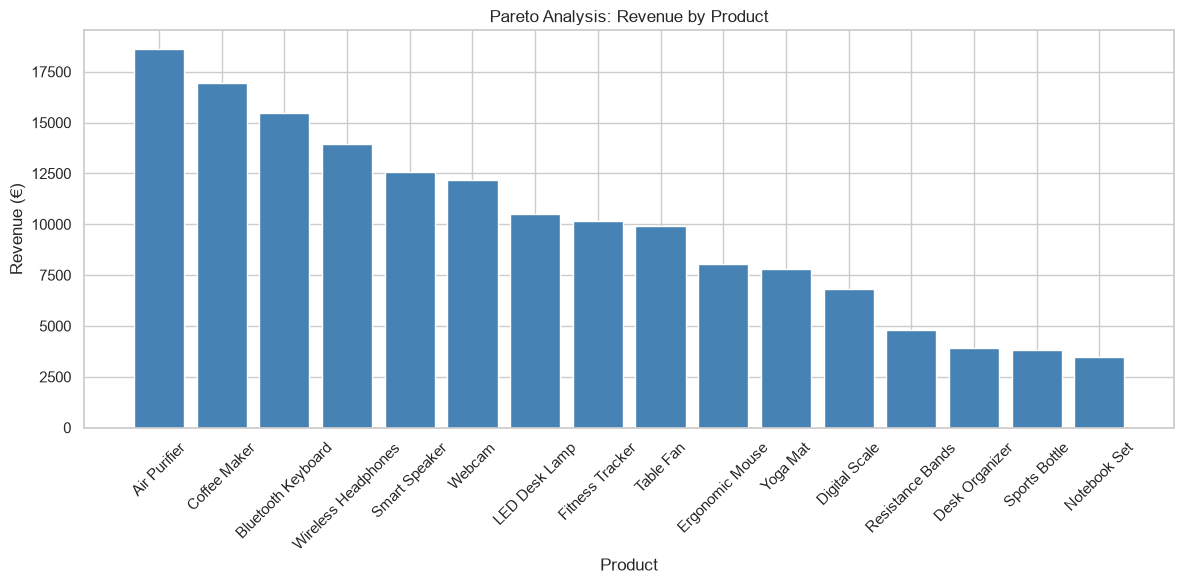

In [39]:
# Create a pareto dataframe
rev_df = pd.DataFrame({
    "revenue_eur": product_rev,
    "revenue_share_pct": rev_share * 100,
    "cumulative_revenue_pct": rev_cum * 100
}).reset_index().rename(columns={"index": "product"})

plt.figure(figsize=(12, 6))
plt.bar(rev_df["product"], rev_df["revenue_eur"], color="steelblue")
plt.title("Pareto Analysis: Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

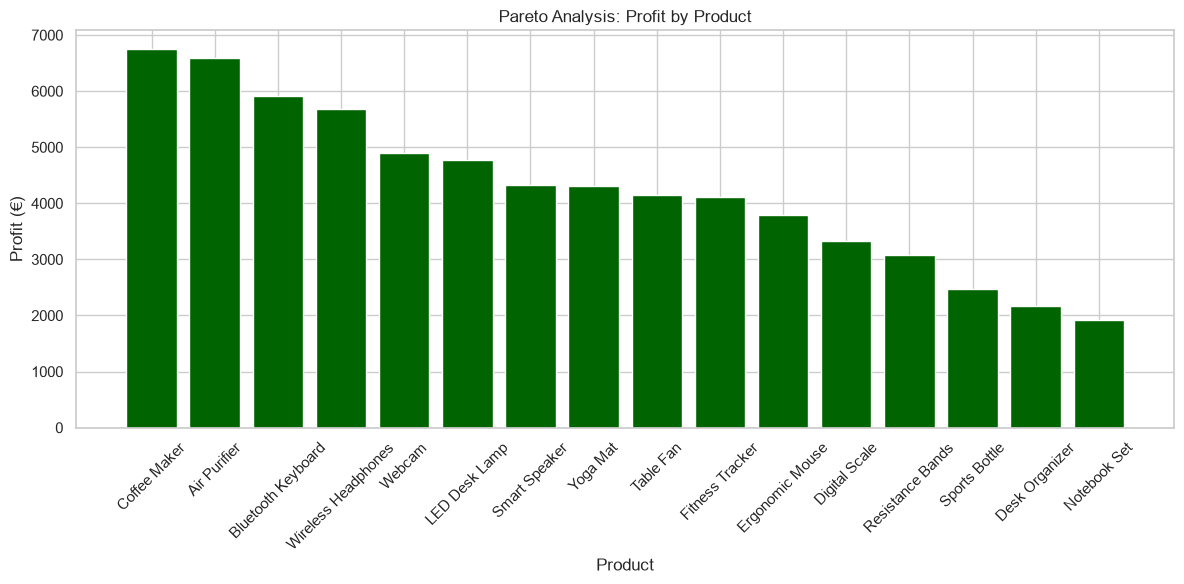

In [38]:
profit_df = pd.DataFrame({
    "profit_eur": product_profit,
    "profit_share_pct": profit_share * 100,
    "cumulative_profit_pct": profit_cum * 100
}).reset_index().rename(columns={"index": "product"})

plt.figure(figsize=(12, 6))
plt.bar(profit_df["product"], profit_df["profit_eur"], color="darkgreen")
plt.title("Pareto Analysis: Profit by Product")
plt.xlabel("Product")
plt.ylabel("Profit (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()